In [3]:
import numpy as np
import cv2
import os
import shutil
import pywt
from matplotlib import pyplot as plt 
%matplotlib inline

In [4]:
img = cv2.imread("./images_dataset/lionel_messi/02453493f852c0efe8ff951dea5845c4.jpg")
img.shape

(1024, 683, 3)

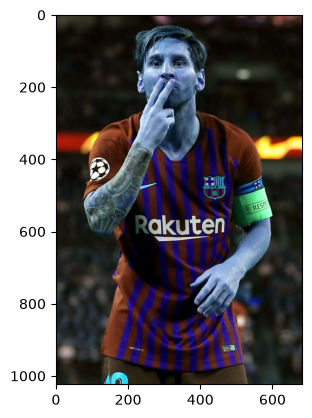

In [5]:
plt.imshow(img)

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(1024, 683)

In [7]:
gray

array([[52, 51, 51, ..., 60, 60, 60],
       [53, 52, 52, ..., 55, 55, 55],
       [53, 53, 52, ..., 49, 49, 49],
       ...,
       [28, 29, 31, ..., 35, 35, 35],
       [28, 30, 31, ..., 34, 34, 34],
       [28, 30, 31, ..., 36, 36, 36]], shape=(1024, 683), dtype=uint8)

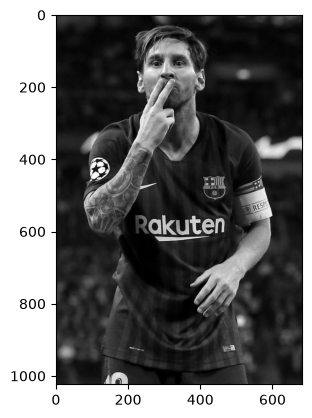

In [8]:
plt.imshow(gray, cmap='gray')

In [9]:
face_cascade = cv2.CascadeClassifier("opencv/haarcascades/haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier("opencv/haarcascades/haarcascade_eye.xml")

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[222,  61, 179, 179]], dtype=int32)

In [10]:
(x, y, w, h) = faces[0]
x, y, w, h

(np.int32(222), np.int32(61), np.int32(179), np.int32(179))

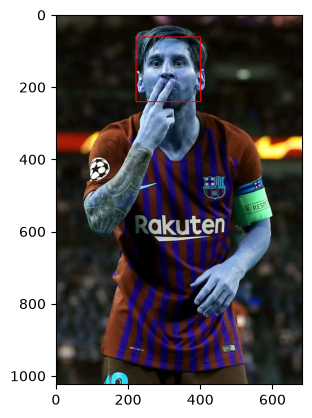

In [11]:
face_img = cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
plt.imshow(face_img)

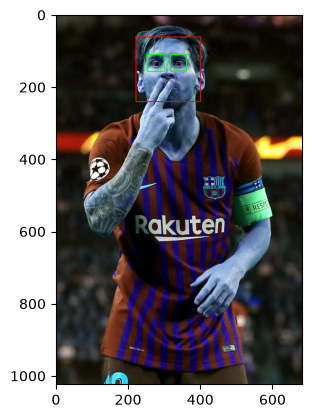

In [12]:
cv2.destroyAllWindows()
for (x, y, w, h) in faces:
    face_img = cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

plt.figure()
plt.imshow(face_img, cmap = 'gray')
plt.show()

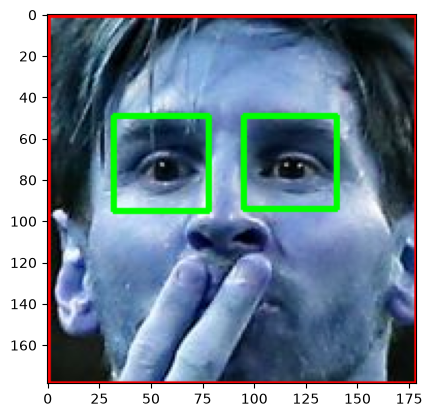

In [13]:
%matplotlib inline
plt.imshow(roi_color, cmap = 'gray')

In [14]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not read image: {image_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        if len(eyes) >= 2:
            return roi_color

    return None

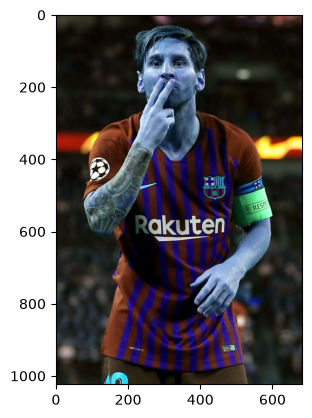

In [15]:
original_image = cv2.imread("./images_dataset/lionel_messi/02453493f852c0efe8ff951dea5845c4.jpg")
plt.imshow(original_image)

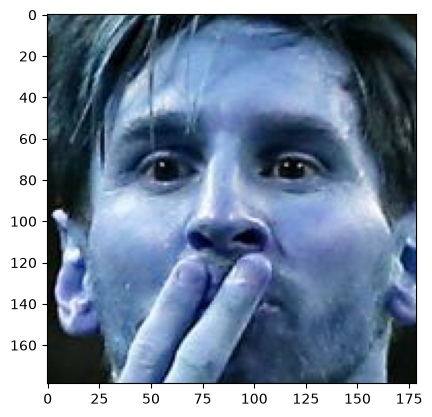

In [16]:
cropped_image = get_cropped_image_if_2_eyes("./images_dataset/lionel_messi/02453493f852c0efe8ff951dea5845c4.jpg")
plt.imshow(cropped_image)

In [17]:
path_to_data = "./images_dataset/"
path_to_cr_data = "./images_dataset/cropped/"

In [18]:
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [19]:
img_dirs

['./images_dataset/maria_sharapova',
 './images_dataset/lionel_messi',
 './images_dataset/roger_federer',
 './images_dataset/cropped',
 './images_dataset/virat_kohli',
 './images_dataset/serena_williams']

In [20]:
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [21]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ", cropped_folder) 
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1
    

maria_sharapova
Generating cropped images in folder:  ./images_dataset/cropped/maria_sharapova
lionel_messi
Generating cropped images in folder:  ./images_dataset/cropped/lionel_messi
roger_federer
Generating cropped images in folder:  ./images_dataset/cropped/roger_federer
cropped
Could not read image: ./images_dataset/cropped/maria_sharapova
Could not read image: ./images_dataset/cropped/lionel_messi
Could not read image: ./images_dataset/cropped/roger_federer
virat_kohli
Generating cropped images in folder:  ./images_dataset/cropped/virat_kohli
serena_williams
Generating cropped images in folder:  ./images_dataset/cropped/serena_williams


In [22]:
def w2d(
    img,
    mode = "haar",
    level = 1
):
    imArray = img
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)
    imArray = np.float32(imArray)
    imArray /= 255
    coeffs = pywt.wavedec2(imArray, mode, level = level)
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)
    
    return imArray_H

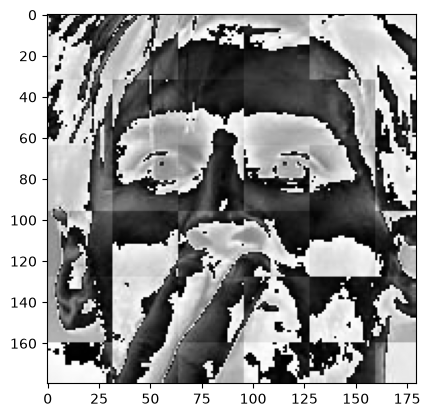

In [23]:
im_har = w2d(cropped_image, 'db1', 5)
plt.imshow(im_har, cmap = 'gray')

In [24]:
celebrity_file_names_dict

{'maria_sharapova': ['./images_dataset/cropped/maria_sharapova/maria_sharapova1.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova2.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova3.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova4.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova5.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova6.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova7.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova8.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova9.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova10.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova11.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova12.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova13.png',
  './images_dataset/cropped/maria_sharapova/maria_sharapova14.png',
  './images_dataset/cropped/maria_shar

In [25]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'maria_sharapova': 0,
 'lionel_messi': 1,
 'roger_federer': 2,
 'cropped': 3,
 'virat_kohli': 4,
 'serena_williams': 5}

In [26]:
x = []
y = []

for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img, 'db1', 5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3, 1), scalled_img_har.reshape(32*32, 1)))
        x.append(combined_img)
        y.append(class_dict[celebrity_name])

In [27]:
print(x)

[array([[168],
       [176],
       [192],
       ...,
       [213],
       [226],
       [  1]], shape=(4096, 1), dtype=uint8), array([[219],
       [234],
       [239],
       ...,
       [105],
       [ 15],
       [ 24]], shape=(4096, 1), dtype=uint8), array([[ 78],
       [158],
       [211],
       ...,
       [209],
       [240],
       [201]], shape=(4096, 1), dtype=uint8), array([[179],
       [194],
       [220],
       ...,
       [251],
       [233],
       [ 37]], shape=(4096, 1), dtype=uint8), array([[218],
       [236],
       [245],
       ...,
       [232],
       [217],
       [173]], shape=(4096, 1), dtype=uint8), array([[ 63],
       [ 73],
       [103],
       ...,
       [213],
       [ 58],
       [243]], shape=(4096, 1), dtype=uint8), array([[104],
       [139],
       [176],
       ...,
       [232],
       [ 38],
       [241]], shape=(4096, 1), dtype=uint8), array([[  8],
       [  4],
       [ 16],
       ...,
       [228],
       [ 35],
       [ 61]], shape=

In [28]:
print(y)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]


In [29]:
len(x[0])

4096

In [30]:
X = np.array(x).reshape(len(x), 4096).astype(float)
X.shape

(187, 4096)

In [31]:
X[0]

array([168., 176., 192., ..., 213., 226.,   1.], shape=(4096,))

# Model Preparation

In [32]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state = 0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, Y_train)
pipe.score(X_test, Y_test)

0.723404255319149